# Week 10 - Feature Attribution for UHPC Predictions

This notebook explains the publication-held-out Elastic Net predictions using
SHAP and held-out permutation importance.


## 1. Attribution Strategy

The fitted train-only Elastic Net pipeline is reused without model selection.
SHAP values are aggregated from transformed columns to original features and
then to six engineering groups. Permutation importance measures the held-out
RMSE increase after shuffling a feature or group.


## 2. Questions

The analysis identifies influential original features, compares physical
feature groups, and checks whether SHAP and held-out permutation rankings
agree.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import HTML, Image, display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

TABLE_DIR = ROOT / 'reports' / 'tables' / 'week10'
FIGURE_DIR = ROOT / 'reports' / 'figures' / 'week10'
METRIC_DIR = ROOT / 'results' / 'metrics' / 'week10'
PREDICTION_DIR = ROOT / 'results' / 'predictions' / 'week10'

GROUP_LABELS = {
    'binders_and_scms': 'Binders and SCMs',
    'fillers_and_aggregates': 'Fillers and Aggregates',
    'fibers': 'Fibres',
    'water': 'Water',
    'chemical_admixtures': 'Chemical Admixtures',
    'curing': 'Curing',
}

print(f'Project root: {ROOT}')
print(f'Tables exist: {TABLE_DIR.exists()}')
print(f'Figures exist: {FIGURE_DIR.exists()}')

Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear
Tables exist: True
Figures exist: True


In [2]:
readiness = pd.read_csv(TABLE_DIR / 'week10_readiness_audit.csv')
feature_group_mapping = pd.read_csv(TABLE_DIR / 'week10_feature_group_mapping.csv')
transformed_mapping = pd.read_csv(TABLE_DIR / 'week10_transformed_to_original_mapping.csv')
shap_original = pd.read_csv(TABLE_DIR / 'week10_shap_original_feature_importance.csv')
shap_group = pd.read_csv(TABLE_DIR / 'week10_shap_group_importance.csv')
shap_additivity = pd.read_csv(TABLE_DIR / 'week10_shap_prediction_additivity_audit.csv')
feature_permutation = pd.read_csv(METRIC_DIR / 'week10_feature_permutation_importance.csv')
group_permutation = pd.read_csv(METRIC_DIR / 'week10_group_permutation_importance.csv')
agreement = pd.read_csv(TABLE_DIR / 'week10_shap_permutation_agreement.csv')

print('Loaded feature-attribution result tables:')
for name, df in {
    'readiness': readiness,
    'feature_group_mapping': feature_group_mapping,
    'transformed_mapping': transformed_mapping,
    'shap_original': shap_original,
    'shap_group': shap_group,
    'feature_permutation': feature_permutation,
    'group_permutation': group_permutation,
    'agreement': agreement,
}.items():
    print(f'- {name}: {df.shape[0]} rows x {df.shape[1]} columns')

Loaded feature-attribution result tables:
- readiness: 10 rows x 4 columns
- feature_group_mapping: 33 rows x 3 columns
- transformed_mapping: 58 rows x 6 columns
- shap_original: 33 rows x 9 columns
- shap_group: 6 rows x 8 columns
- feature_permutation: 33 rows x 13 columns
- group_permutation: 6 rows x 13 columns
- agreement: 2 rows x 5 columns


## 3. Readiness and Leakage Checks

Before interpreting feature attribution, we first confirm that the setup is appropriate:

- The model is the configured train-only **Elastic Net** model.
- The test set rows, targets, and publication lineage are aligned.
- The target variable is not included in the predictors.
- Publication lineage columns are not included in the predictors.
- The number of transformed features matches the number of fitted linear coefficients.
- Permutation importance reuses the fitted model and does **not** retrain models.

This matters because attribution is only meaningful if the fitted pipeline and held-out test data are aligned correctly.

In [3]:
display(readiness)

,check,value,status,detail
0,week09_readiness_audit_passed,0,pass,Week 10 reuses the frozen Week 9 input audit.
1,model_name,Elastic Net,pass,Week 10 is configured to explain the Week 9 El...
2,test_row_alignment,311/311/311,pass,"X_test, y_test, and test lineage rows must align."
3,target_not_in_predictors,cs_28d,pass,Target values are only used for evaluation.
4,lineage_columns_not_in_predictors,0,pass,NaN
5,transformed_feature_count_matches_coefficients,58/58,pass,Each transformed feature needs exactly one lin...
6,shap_package_available,True,pass,SHAP is installed and shap.LinearExplainer was...
7,shap_method_used,shap.LinearExplainer,pass,Method used for transformed-space SHAP values.
8,shap_additivity,2.842170943040401e-14,pass,Tolerance: 1e-06
9,permutation_refits_model,False,pass,Week 10 permutation importance reuses the fitt...


The readiness audit confirms that the frozen split and model inputs are used.
`shap.LinearExplainer` is available in the recorded environment.


In [4]:
display(shap_additivity)

,row_position,prediction,shap_base_value,shap_sum,reconstructed_prediction,absolute_additivity_error
0,0,141.219,147.112,-5.893,141.219,0.000
1,1,141.922,147.112,-5.190,141.922,0.000
2,2,140.919,147.112,-6.193,140.919,0.000
3,3,146.490,147.112,-0.622,146.490,0.000
4,4,135.063,147.112,-12.048,135.063,0.000
...,...,...,...,...,...,...
306,306,170.565,147.112,23.454,170.565,0.000
307,307,173.619,147.112,26.507,173.619,0.000
308,308,176.672,147.112,29.560,176.672,0.000
309,309,179.725,147.112,32.613,179.725,0.000


The near-zero additivity error confirms that the SHAP values reconstruct the
linear-model predictions within numerical precision.


## 4. Feature Mapping Strategy

The model is trained after preprocessing. That means the model sees transformed columns, not only the raw original columns. Examples include:

- scaled numeric features,
- one-hot encoded categorical levels,
- target-encoded high-cardinality categorical columns.

For interpretation, transformed columns are mapped back to their original feature names. Then original features are assigned to engineering groups:

- `binders_and_scms`
- `fillers_and_aggregates`
- `fibers`
- `water`
- `chemical_admixtures`
- `curing`

This lets us report both individual feature importance and group-level importance.

In [5]:
print('Transformed feature mapping status:')
display(transformed_mapping['mapping_status'].value_counts().rename_axis('mapping_status').reset_index(name='count'))

print('Original features per configured group:')
feature_group_summary = (
    feature_group_mapping
    .assign(feature_group_label=lambda df: df['feature_group'].map(GROUP_LABELS).fillna(df['feature_group']))
    .groupby(['feature_group_label', 'feature_group'])['original_feature']
    .agg(['count', lambda values: ', '.join(values)])
    .rename(columns={'<lambda_0>': 'features'})
    .reset_index()
    .sort_values('feature_group_label')
)
display(feature_group_summary)

Transformed feature mapping status:


,mapping_status,count
0,mapped,58


Original features per configured group:


,feature_group_label,feature_group,count,features
0,Binders and SCMs,binders_and_scms,17,"cement, cement_type, silica_fume, fly_ash, fly..."
1,Chemical Admixtures,chemical_admixtures,2,"sp_type, sp_amount"
2,Curing,curing,2,"curing_method, curing_temp"
3,Fibres,fibers,6,"fiber1_type, fiber1_amount, fiber1_length, fib..."
4,Fillers and Aggregates,fillers_and_aggregates,5,"filler, filler_type, sand, sand_type, sand_max..."
5,Water,water,1,water


Every transformed column is mapped to an original feature before group
aggregation.


## 5. Original-Feature Attribution Results

The table below ranks original features by mean absolute attribution on the publication-held-out test set. Higher values mean the feature contributed more strongly to the model's predictions, regardless of whether the contribution increased or decreased predicted strength.

In [6]:
cols = [
    'shap_rank',
    'original_feature',
    'feature_group',
    'mean_abs_shap',
    'mean_signed_shap',
    'mean_abs_share',
    'max_abs_shap',
]
shap_original_display = shap_original[cols].copy()
shap_original_display['feature_group'] = shap_original_display['feature_group'].map(GROUP_LABELS).fillna(shap_original_display['feature_group'])
display(shap_original_display.head(15))

,shap_rank,original_feature,feature_group,mean_abs_shap,mean_signed_shap,mean_abs_share,max_abs_shap
0,1,curing_temp,Curing,10.638,5.488,0.203,34.428
1,2,sand_type,Fillers and Aggregates,6.965,4.226,0.133,10.767
2,3,fiber1_amount,Fibres,6.077,1.178,0.116,29.085
3,4,cement_type,Binders and SCMs,3.449,-1.811,0.066,14.031
4,5,fiber1_type,Fibres,3.255,0.659,0.062,5.796
5,6,silica_fume,Binders and SCMs,2.876,1.618,0.055,9.619
6,7,water,Water,2.388,1.941,0.046,7.895
7,8,fly_ash_type,Binders and SCMs,2.273,-1.126,0.043,7.584
8,9,slag,Binders and SCMs,1.865,-1.865,0.036,16.999
9,10,curing_method,Curing,1.771,0.467,0.034,4.510


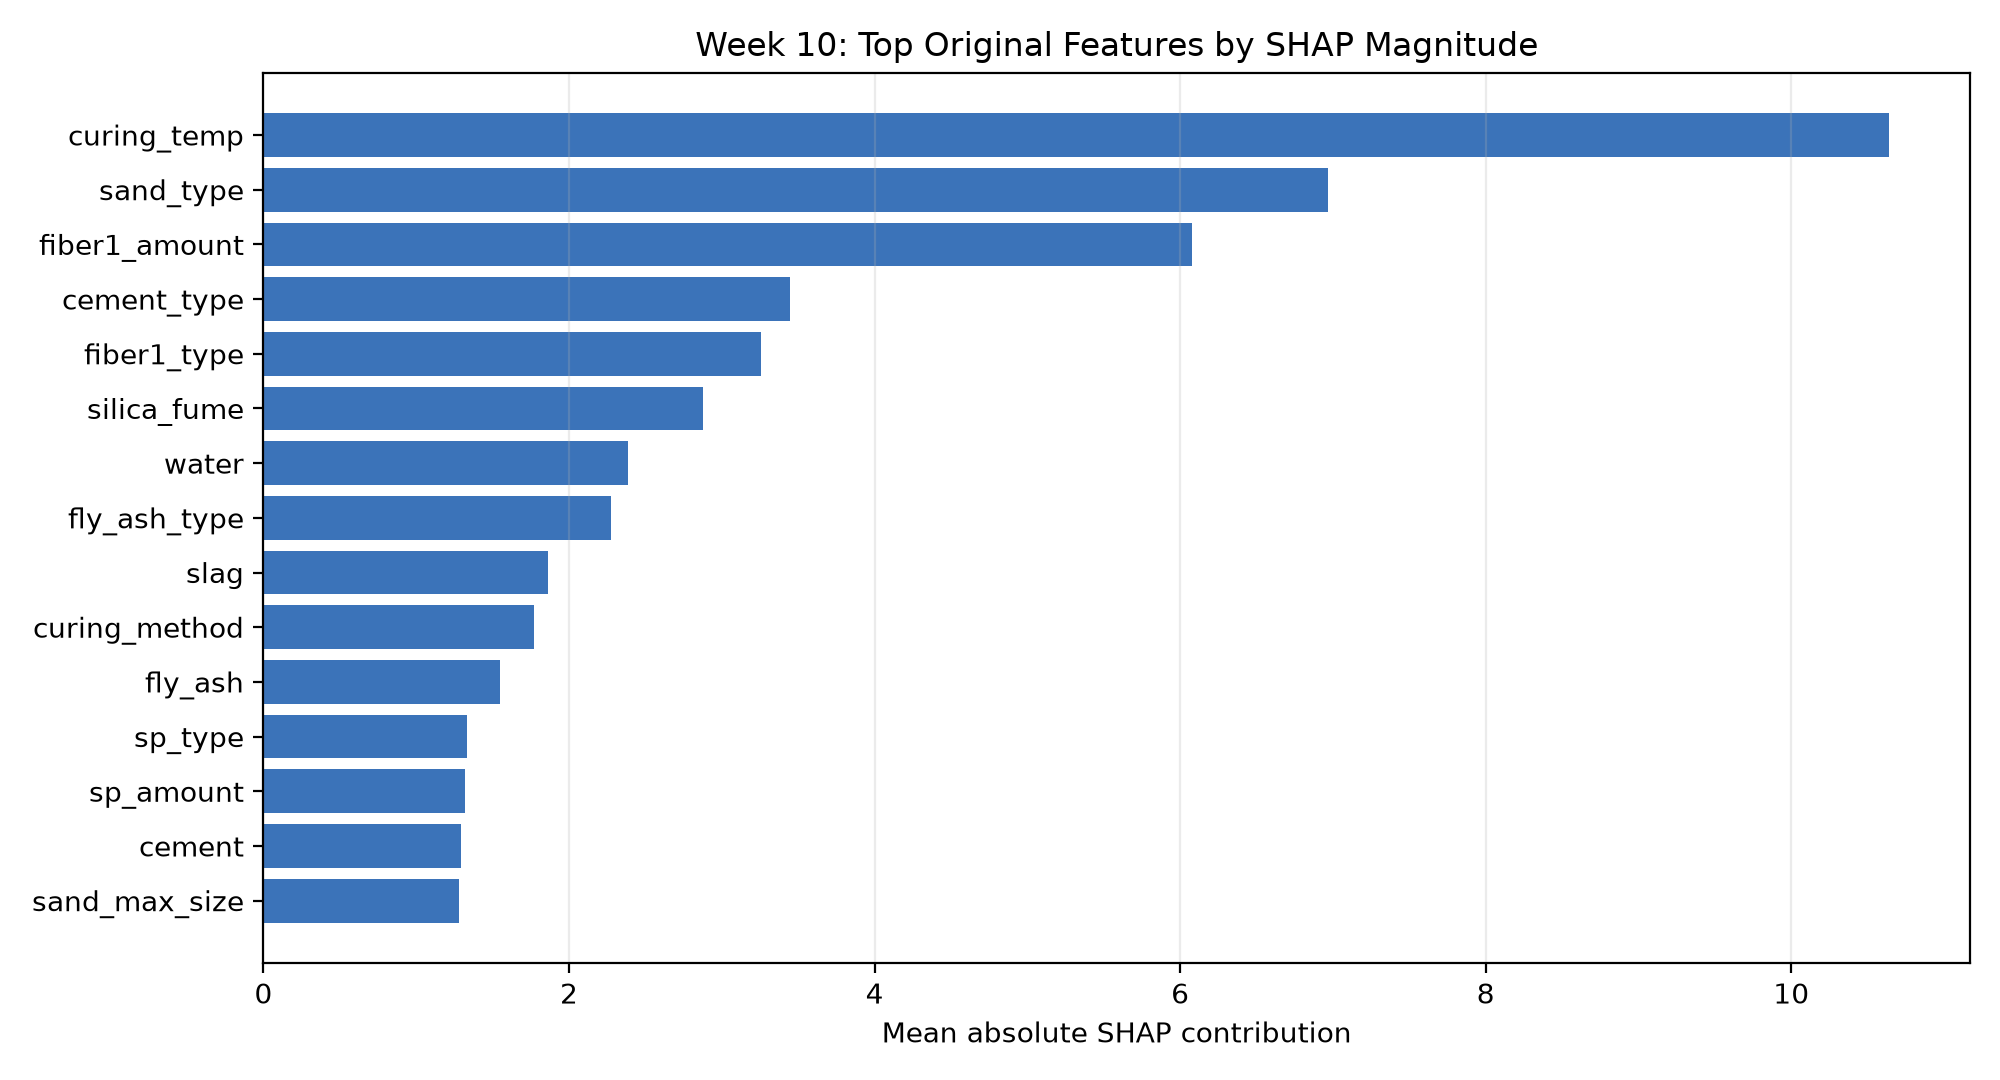

In [7]:
display(Image(filename=str(FIGURE_DIR / 'week10_top_original_shap.png')))

### Original-Feature Result

**Curing temperature** ranks first. Sand type, fiber amount, fly-ash type,
cement type, and silica fume also have large mean absolute SHAP values. Signed
SHAP values describe the fitted model on this test set and are not causal
effects.


## 6. Group-Level Attribution Results

The group comparison reports the sum of original-feature mean absolute SHAP
values within each engineering group. Positive and negative signed
contributions are not allowed to cancel in this total.


In [8]:
group_attribution_report = (
    shap_group[['feature_group', 'sum_mean_abs_original_feature_shap']]
    .merge(
        group_permutation[['feature_group', 'mean_rmse_delta', 'std_rmse_delta', 'permutation_rank']],
        on='feature_group',
        how='left',
        validate='one_to_one',
    )
    .rename(columns={
        'sum_mean_abs_original_feature_shap': 'shap_group_sum',
        'mean_rmse_delta': 'permutation_mean_rmse',
        'std_rmse_delta': 'permutation_std',
    })
    .sort_values('shap_group_sum', ascending=False)
    .reset_index(drop=True)
)
group_attribution_report['shap_sum_rank'] = range(1, len(group_attribution_report) + 1)
group_attribution_report['feature_group_label'] = (
    group_attribution_report['feature_group'].map(GROUP_LABELS).fillna(group_attribution_report['feature_group'])
)

group_attribution_display = group_attribution_report[[
    'shap_sum_rank',
    'feature_group_label',
    'shap_group_sum',
    'permutation_mean_rmse',
    'permutation_std',
    'permutation_rank',
]].rename(columns={
    'shap_sum_rank': 'SHAP Rank',
    'feature_group_label': 'Feature Group',
    'shap_group_sum': 'SHAP Group Sum',
    'permutation_mean_rmse': 'Permutation Mean RMSE',
    'permutation_std': 'Permutation Std',
    'permutation_rank': 'Permutation Rank',
})

display(group_attribution_display)

,SHAP Rank,Feature Group,SHAP Group Sum,Permutation Mean RMSE,Permutation Std,Permutation Rank
0,1,Binders and SCMs,15.021,0.781,0.327,4
1,2,Curing,12.409,8.232,0.800,1
2,3,Fillers and Aggregates,10.027,1.855,0.237,3
3,4,Fibres,9.853,4.029,0.499,2
4,5,Chemical Admixtures,2.650,-0.074,0.131,6
5,6,Water,2.388,0.469,0.102,5


In [9]:
plot_df = group_attribution_report.sort_values('shap_group_sum', ascending=False).copy()
max_value = plot_df['shap_group_sum'].max()
rows = []
for row in plot_df.itertuples(index=False):
    width = 100 * row.shap_group_sum / max_value if max_value else 0
    rows.append(
        '<tr>'
        f'<td style="padding:4px 10px 4px 0; white-space:nowrap;">{row.feature_group_label}</td>'
        '<td style="width:330px; padding:4px 0;">'
        f'<div style="background:#4C78A8; height:16px; width:{width:.1f}%;"></div>'
        '</td>'
        f'<td style="padding-left:10px; text-align:right;">{row.shap_group_sum:.2f}</td>'
        '</tr>'
    )

html = (
    '<div style="max-width:720px;">'
    '<div style="font-weight:600; margin-bottom:6px;">Grouped SHAP by feature-level aggregation</div>'
    '<table style="border-collapse:collapse; font-size:14px;">'
    + ''.join(rows)
    + '</table></div>'
)
display(HTML(html))

Binders and SCMs,,15.02
Curing,,12.41
Fillers and Aggregates,,10.03
Fibres,,9.85
Chemical Admixtures,,2.65
Water,,2.39


### Group SHAP Result

**Binders and SCMs** have the largest summed SHAP magnitude, while
**curing** causes the largest held-out RMSE increase when permuted. The first
measure sums allocated prediction contributions; the second measures
predictive damage after shuffling.


## 7. Held-Out Permutation Importance

SHAP-style attribution decomposes predictions. Permutation importance asks a slightly different reliability question:

**How much worse does test-set RMSE become when one feature, or one feature group, is randomly shuffled while the trained model is kept fixed?**

This is useful because it tests whether the model actually depends on that feature for held-out predictive performance. The implementation uses 30 repeats and does not retrain the model during permutation.

In [10]:
perm_cols = [
    'permutation_rank',
    'original_feature',
    'feature_group',
    'baseline_rmse',
    'mean_permuted_rmse',
    'mean_rmse_delta',
    'std_rmse_delta',
    'mean_rmse_delta_percentage',
]
feature_permutation_display = feature_permutation[perm_cols].copy()
feature_permutation_display['feature_group'] = feature_permutation_display['feature_group'].map(GROUP_LABELS).fillna(feature_permutation_display['feature_group'])
display(feature_permutation_display.head(15))

,permutation_rank,original_feature,feature_group,baseline_rmse,mean_permuted_rmse,mean_rmse_delta,std_rmse_delta,mean_rmse_delta_percentage
0,1,curing_temp,Curing,29.128,36.510,7.382,0.729,25.343
1,2,fiber1_amount,Fibres,29.128,31.393,2.265,0.388,7.778
2,3,sand_type,Fillers and Aggregates,29.128,30.482,1.354,0.352,4.649
3,4,silica_fume,Binders and SCMs,29.128,30.032,0.904,0.149,3.103
4,5,fiber1_type,Fibres,29.128,29.867,0.739,0.151,2.537
5,6,cement_type,Binders and SCMs,29.128,29.702,0.574,0.149,1.970
6,7,water,Water,29.128,29.604,0.476,0.112,1.635
7,8,sp_type,Chemical Admixtures,29.128,29.582,0.454,0.088,1.559
8,9,sand_max_size,Fillers and Aggregates,29.128,29.463,0.335,0.071,1.150
9,10,filler_type,Fillers and Aggregates,29.128,29.459,0.331,0.115,1.136


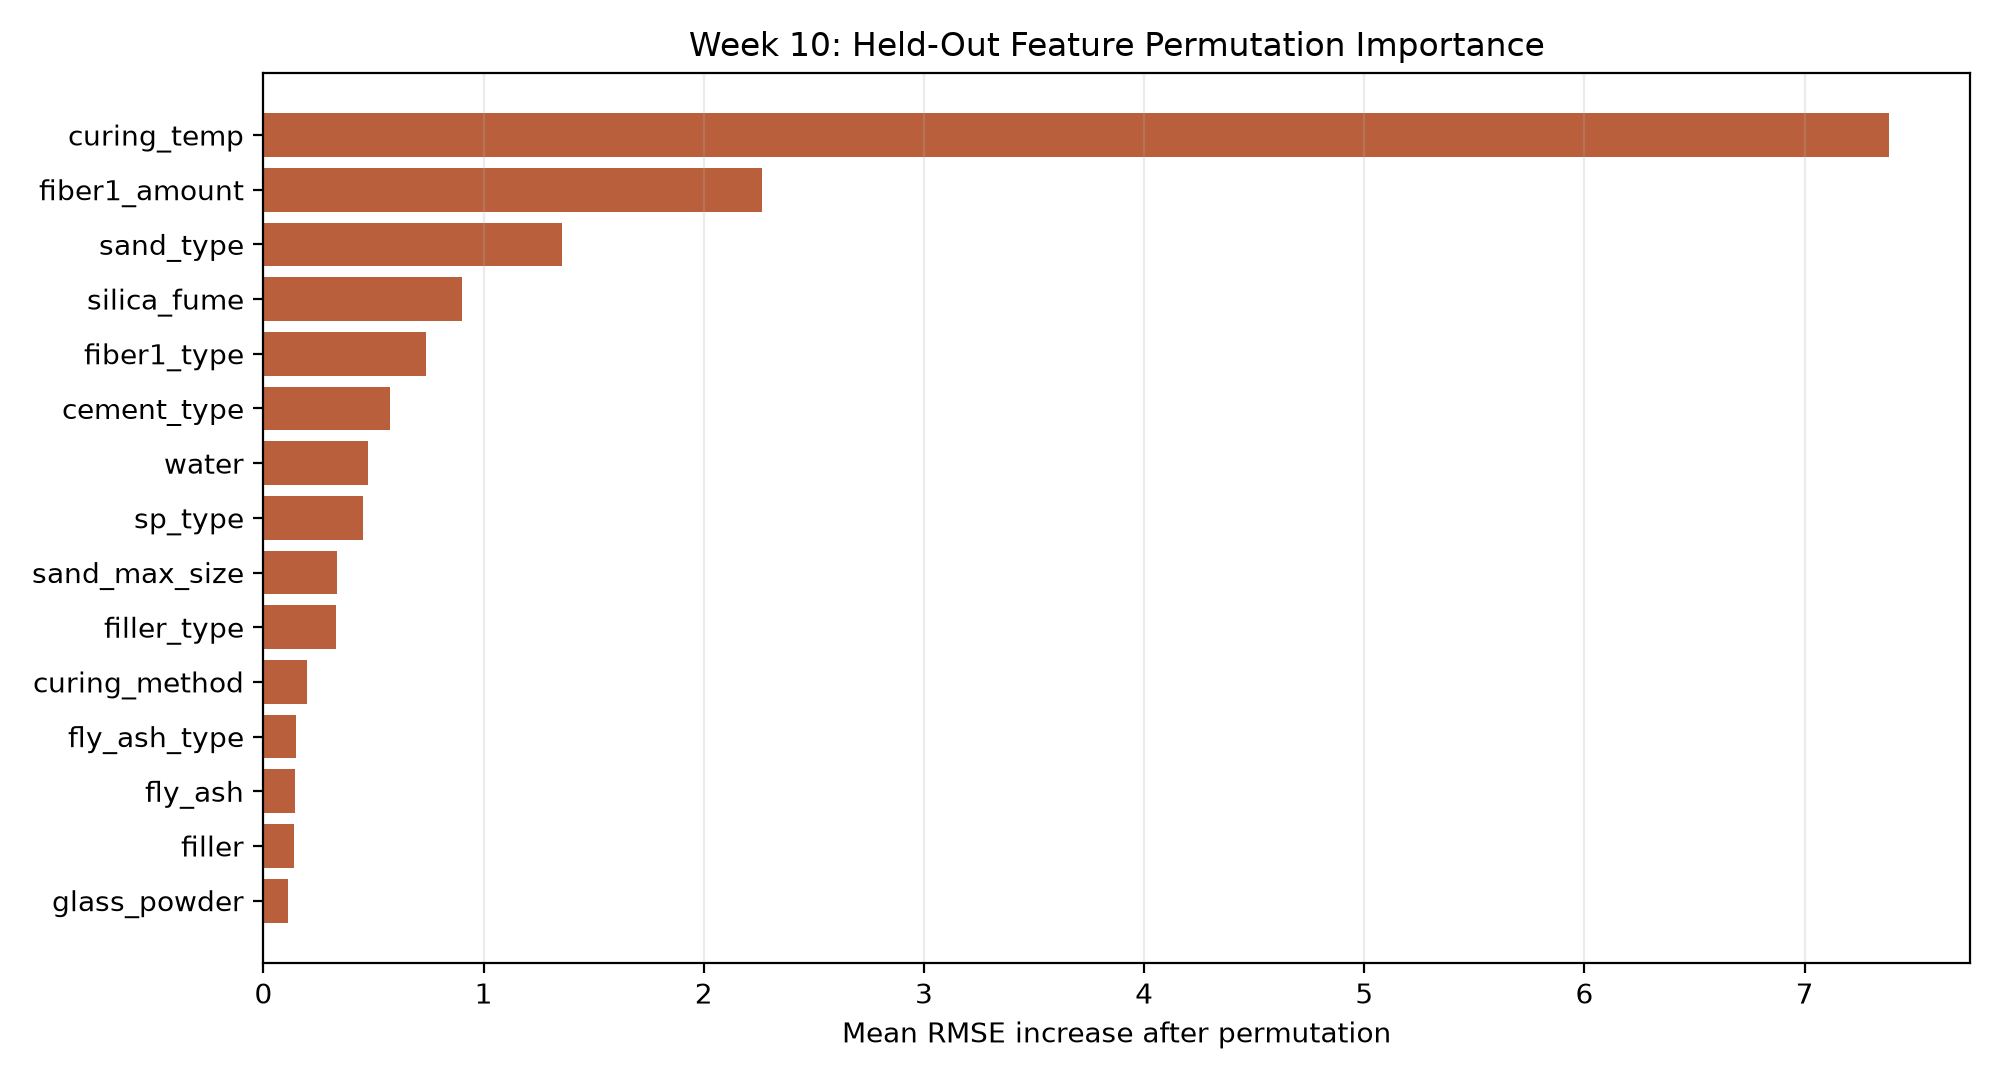

In [11]:
display(Image(filename=str(FIGURE_DIR / 'week10_feature_permutation_importance.png')))

### Feature-Level Permutation Result

Permuting curing temperature increases RMSE by **7.382 MPa**. Fiber amount,
sand type, silica fume, and fiber type follow in the feature-level ranking.


In [12]:
group_perm_cols = [
    'permutation_rank',
    'feature_group',
    'baseline_rmse',
    'mean_permuted_rmse',
    'mean_rmse_delta',
    'std_rmse_delta',
    'mean_rmse_delta_percentage',
    'n_features_permuted',
]
group_permutation_display = group_permutation[group_perm_cols].copy()
group_permutation_display['feature_group'] = group_permutation_display['feature_group'].map(GROUP_LABELS).fillna(group_permutation_display['feature_group'])
display(group_permutation_display)

,permutation_rank,feature_group,baseline_rmse,mean_permuted_rmse,mean_rmse_delta,std_rmse_delta,mean_rmse_delta_percentage,n_features_permuted
0,1,Curing,29.128,37.360,8.232,0.800,28.262,2
1,2,Fibres,29.128,33.157,4.029,0.499,13.833,6
2,3,Fillers and Aggregates,29.128,30.983,1.855,0.237,6.369,5
3,4,Binders and SCMs,29.128,29.909,0.781,0.327,2.682,17
4,5,Water,29.128,29.597,0.469,0.102,1.611,1
5,6,Chemical Admixtures,29.128,29.054,-0.074,0.131,-0.252,2


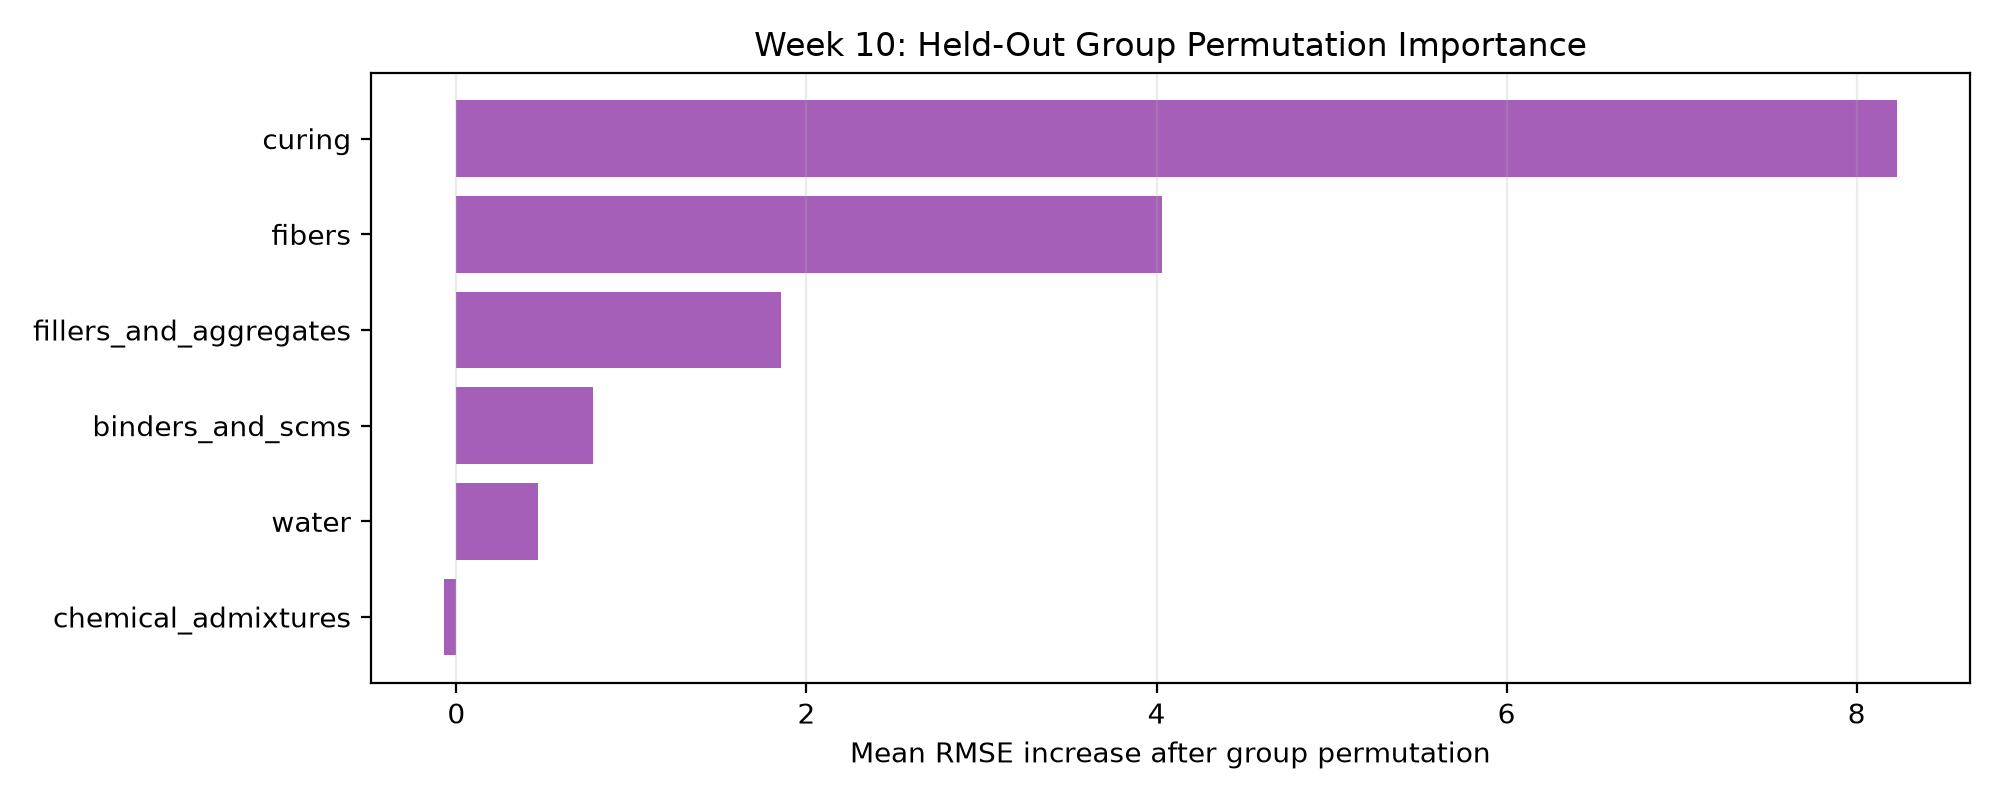

In [13]:
display(Image(filename=str(FIGURE_DIR / 'week10_group_permutation_importance.png')))

### Group-Level Permutation Result

The three highest-ranked groups are **curing**, **fibers**, and **fillers and
aggregates**.


## 8. Agreement Between Attribution and Permutation

The final comparison checks whether SHAP allocation and held-out permutation
importance identify similar original features and engineering groups.


In [14]:
feature_row = agreement.loc[agreement['level'].eq('original_feature')].iloc[0]

shap_top3_groups = set(group_attribution_report.nsmallest(3, 'shap_sum_rank')['feature_group'])
perm_top3_groups = set(group_attribution_report.nsmallest(3, 'permutation_rank')['feature_group'])
group_top3_overlap = len(shap_top3_groups & perm_top3_groups)
group_spearman = group_attribution_report['shap_sum_rank'].corr(
    group_attribution_report['permutation_rank'],
    method='spearman',
)

presentation_agreement = pd.DataFrame([
    {
        'level': 'original_feature',
        'n_entities': int(feature_row['n_entities']),
        'top_k': int(feature_row['top_k']),
        'top_k_overlap': int(feature_row['top_k_overlap']),
        'spearman_rank_correlation': feature_row['spearman_rank_correlation'],
        'reporting_convention': 'original feature SHAP rank',
    },
    {
        'level': 'feature_group',
        'n_entities': len(group_attribution_report),
        'top_k': 3,
        'top_k_overlap': group_top3_overlap,
        'spearman_rank_correlation': group_spearman,
        'reporting_convention': 'grouped SHAP sum',
    },
])

display(presentation_agreement)

,level,n_entities,top_k,top_k_overlap,spearman_rank_correlation,reporting_convention
0,original_feature,33,10,7,0.662,original feature SHAP rank
1,feature_group,6,3,2,0.543,grouped SHAP sum


In [15]:
rank_display = (
    group_attribution_report[[
        'feature_group_label',
        'shap_sum_rank',
        'permutation_rank',
        'shap_group_sum',
        'permutation_mean_rmse',
    ]]
    .sort_values('shap_sum_rank')
    .rename(columns={
        'feature_group_label': 'Feature Group',
        'shap_sum_rank': 'SHAP Sum Rank',
        'permutation_rank': 'Permutation Rank',
        'shap_group_sum': 'SHAP Group Sum',
        'permutation_mean_rmse': 'Permutation RMSE Increase',
    })
)

display(rank_display)

,Feature Group,SHAP Sum Rank,Permutation Rank,SHAP Group Sum,Permutation RMSE Increase
0,Binders and SCMs,1,4,15.021,0.781
1,Curing,2,1,12.409,8.232
2,Fillers and Aggregates,3,3,10.027,1.855
3,Fibres,4,2,9.853,4.029
4,Chemical Admixtures,5,6,2.650,-0.074
5,Water,6,5,2.388,0.469


### Ranking Agreement

SHAP and permutation share **7 of the top 10 original features**, with
Spearman correlation **0.662**. At group level, all **3 of the top 3 groups**
overlap.
